In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import os 
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# PLSSVD: fixed-dimension generalization to held-out trials
Five shuffled folds, with each trial held out exactly once (approximately 80% train / 20% test per fold). Trial assignment is stratified by subject and condition. Fit and test on these condition-averaged time courses.

submit_to_cluster -n 2 -q short.q "python plssvd_eval.py --meg-kind full_average --n-components 5 --n-splits 5 --output-dir /path/to/plssvd_eval_full_average" --project MINDLAB2021_MEG-TempSeqAges


In [2]:
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT.parent))
sys.path.insert(0, str(ROOT.parent / 'LB'))
from plssvd_eval_utils import (ValidationOptions, 
                               prepare_trial_cache, load_trial_cache,
                               validate_plssvd, plot_plssvd_validation, 
                               load_plssvd_results,)

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

In [13]:
MEG_KIND = 'full_concatenated'
options = ValidationOptions(n_components=5, 
                            repeats=5,n_null=199, 
                            seed=2026, split_unit='trial', 
                            block_scaling='none')
CACHE_DIR = ROOT / 'out' / 'trial_cache'
OUTPUT_DIR = ROOT / 'out' / 'plssvd_eval' / MEG_KIND

## Trial cache and fold assignment
The cache contains unaveraged trials. For five folds, every subject/condition needs at least five trials. Within each subject and condition, shuffle once and divide into five nearly equal chunks. Fold f tests on chunk f and trains on the other four. Test chunks are disjoint and exhaust all trials.

Optional metadata columns are `modality`, `subject`, `condition`, `trial_index` (within condition), and `split_group`. With `split_unit='group'`, whole groups are held out together across conditions; at least five distinct groups and nonempty conditions in every fold are required. Unequal group sizes can give unequal test sizes. `permutation_block` is retained for compatibility with other workflows; this condition-averaged evaluation does not use a condition-label null.


In [14]:
result = load_plssvd_results(OUTPUT_DIR)
if result['validation_options'].get('schema_version', 1) < 3:
    raise ValueError('These results predate disjoint folds and condition averaging. Run the updated batch script into a new directory.')
MEG_KIND = result['validation_options']['meg_kind']
print(f"Loaded {MEG_KIND}: {result['validation_options']['repeats']} disjoint test folds, "
      f"fixed k={result['validation_options']['n_components']}")
display(pd.Series(result['validation_options'], name='Saved evaluation settings'))
display(result['trial_counts'] if not result['trial_counts'].empty else result['participants'])


Loaded full_concatenated: 5 disjoint test folds, fixed k=5


repeats                                                               5
n_components                                                          5
n_null                                                              199
seed                                                               2026
split_unit                                                        trial
block_scaling                                                      none
ridge                                                             0.001
max_gram_gib                                                        2.0
schema_version                                                        3
meg_kind                                              full_concatenated
design                fixed-k shuffled disjoint test folds; conditio...
condition_mode                                                  average
partitions                                                [train, test]
ieeg_preprocessing                                fixed multipli

,modality,subject,condition,n_trials,n_channels,n_times
0,ieeg,BJH026,1,24,70,1025
1,ieeg,BJH026,2,24,70,1025
2,ieeg,BJH027,1,24,137,1025
3,ieeg,BJH027,2,24,137,1025
4,ieeg,BJH029,1,24,133,1025
...,...,...,...,...,...,...
117,meg,SUBJ_0036,2,23,3559,1025
118,meg,SUBJ_0037,1,20,3559,1025
119,meg,SUBJ_0037,2,25,3559,1025
120,meg,SUBJ_0039,1,24,3559,1025


## Fit and test on averaged responses
For each subject, separately in train and test:
1. Average selected trials within each condition.
2. Apply the existing preprocessing using training-estimated parameters.
3. Average condition responses with equal weight.

`split_audit` records only train/test membership. Each trial appears once as test and four times as training with five folds. Training sets overlap; test sets do not.

In [15]:
display(result['summary'].round(3))
display(result['metric_summary'].query("partition == 'test'").round(3))

,repeat,n_components,n_ieeg,n_meg,n_meg_contributing,train_mean_r,test_mean_r,predict_ieeg_q2,predict_meg_q2,train_ieeg_reconstruction_fraction,...,test_ieeg_reconstruction_fraction,test_predict_ieeg_q2,test_meg_reconstruction_fraction,test_predict_meg_q2,test_crosscov_energy_fraction,test_paired_crosscov_energy_fraction,test_mean_paired_covariance,test_total_crosscov_energy,test_captured_crosscov_energy,paired_covariance_retention
0,0,5,30,31,31,0.906,0.793,0.139,0.053,0.589,...,0.171,0.139,0.072,0.053,0.204,0.199,161.413,1252768.118,255632.809,0.711
1,1,5,30,31,31,0.910,0.724,0.112,0.048,0.603,...,0.167,0.112,0.072,0.048,0.189,0.185,142.025,1066138.078,201513.859,0.608
2,2,5,30,31,31,0.911,0.744,0.096,0.043,0.602,...,0.171,0.096,0.069,0.043,0.186,0.180,146.605,1124792.731,209482.374,0.627
3,3,5,30,31,31,0.911,0.723,0.100,0.046,0.601,...,0.151,0.100,0.068,0.046,0.164,0.158,144.789,1277295.429,209204.936,0.625
4,4,5,30,31,31,0.906,0.767,0.090,0.040,0.599,...,0.159,0.090,0.069,0.040,0.173,0.169,161.425,1468134.511,253955.203,0.700


,partition,metric,count,mean,std,median,min,max
1,test,ieeg_reconstruction_fraction,5,0.164,0.009,0.167,0.151,0.171
3,test,predict_ieeg_q2,5,0.107,0.019,0.100,0.090,0.139
5,test,meg_reconstruction_fraction,5,0.070,0.002,0.069,0.068,0.072
7,test,predict_meg_q2,5,0.046,0.005,0.046,0.040,0.053
9,test,crosscov_energy_fraction,5,0.183,0.015,0.186,0.164,0.204
11,test,paired_crosscov_energy_fraction,5,0.178,0.016,0.180,0.158,0.199
13,test,mean_paired_covariance,5,151.251,9.424,146.605,142.025,161.425
15,test,total_crosscov_energy,5,1237825.773,155785.410,1252768.118,1066138.078,1468134.511
17,test,captured_crosscov_energy,5,225957.836,26523.881,209482.374,201513.859,255632.809
19,test,mean_r,5,0.750,0.030,0.744,0.723,0.793


## Goodness on held-out data: signal fit and shared covariance

**1. Own-modality reconstruction.** For each modality, project the test signals onto the training-learned PLS weight space and reconstruct them using the same weights:
Any training whole-modality scale is undone for reconstruction. `ieeg_reconstruction_fraction` and `meg_reconstruction_fraction` report how much of each test signal the learned space retains.

**2. Cross-modal prediction.** Training ridge regressions map MEG scores to iEEG features and iEEG scores to MEG features. `predict_ieeg_q2` and `predict_meg_q2` are `1 − test squared error / training-mean-baseline squared error`. Positive Q² improves on that baseline; negative Q² is worse.

**3. Held-out cross-covariance.** Let C be the full test-feature cross-covariance after partition centering and the training-learned scaling, and let Wx/Wy be the training PLS weights. The test score covariance matrix is `Wx.T @ C @ Wy`. `crosscov_energy_fraction` is its squared Frobenius norm divided by `||C||F²`.This is the fraction of observed test cross-covariance energy retained by the trained spaces.

Also report `mean_paired_covariance` (signed diagonal mean in native score units), per-component train/test covariance, `paired_crosscov_energy_fraction` (diagonal energy only), and signed paired score Pearson r. A covariance fraction can be high even when the absolute shared signal is weak, so inspect these measures together. Covariance retention relative to training is in `summary.csv` and can exceed one or become negative.

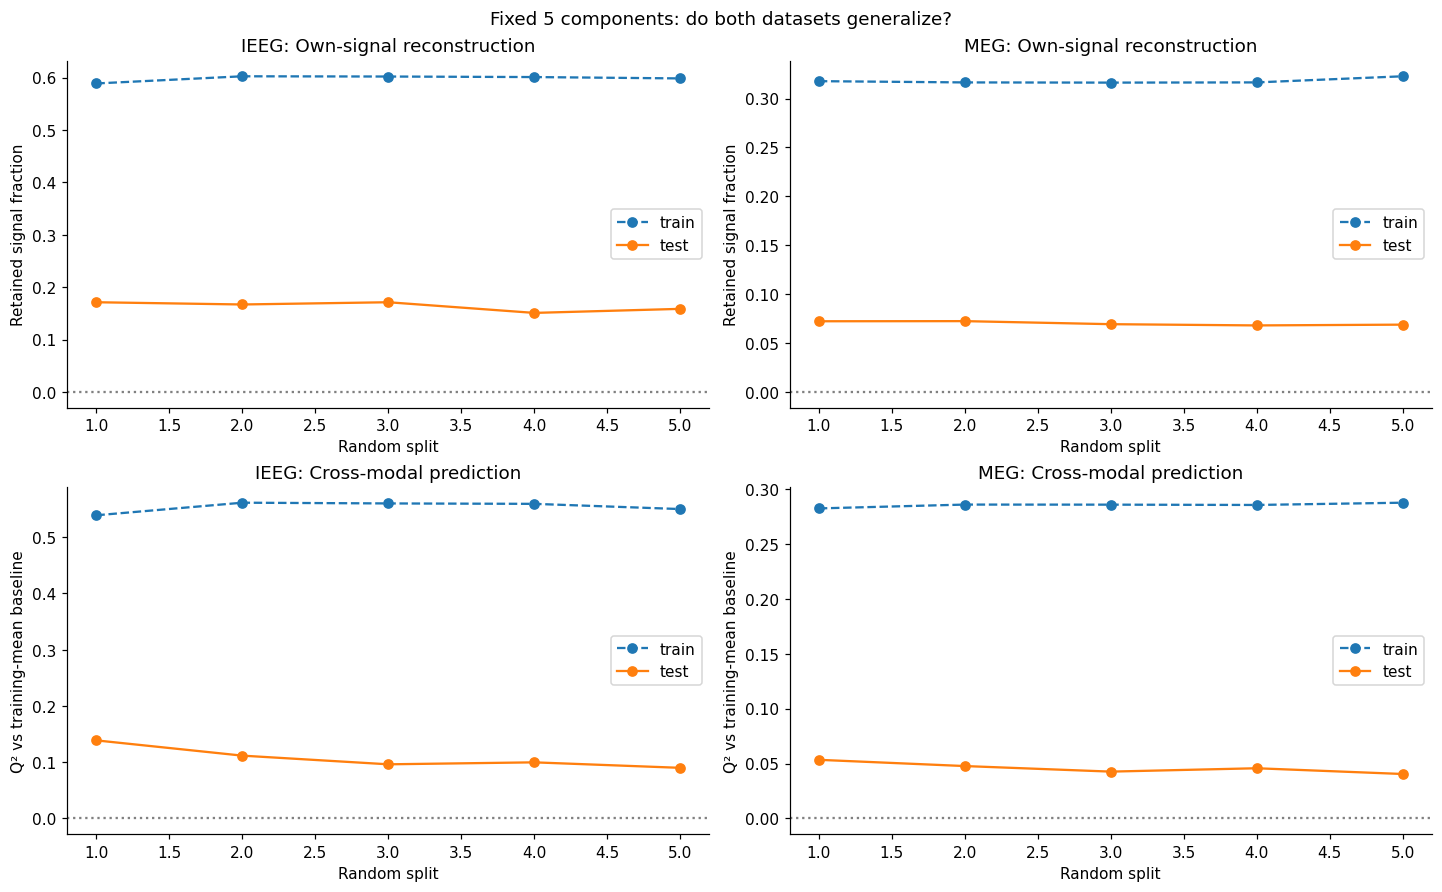

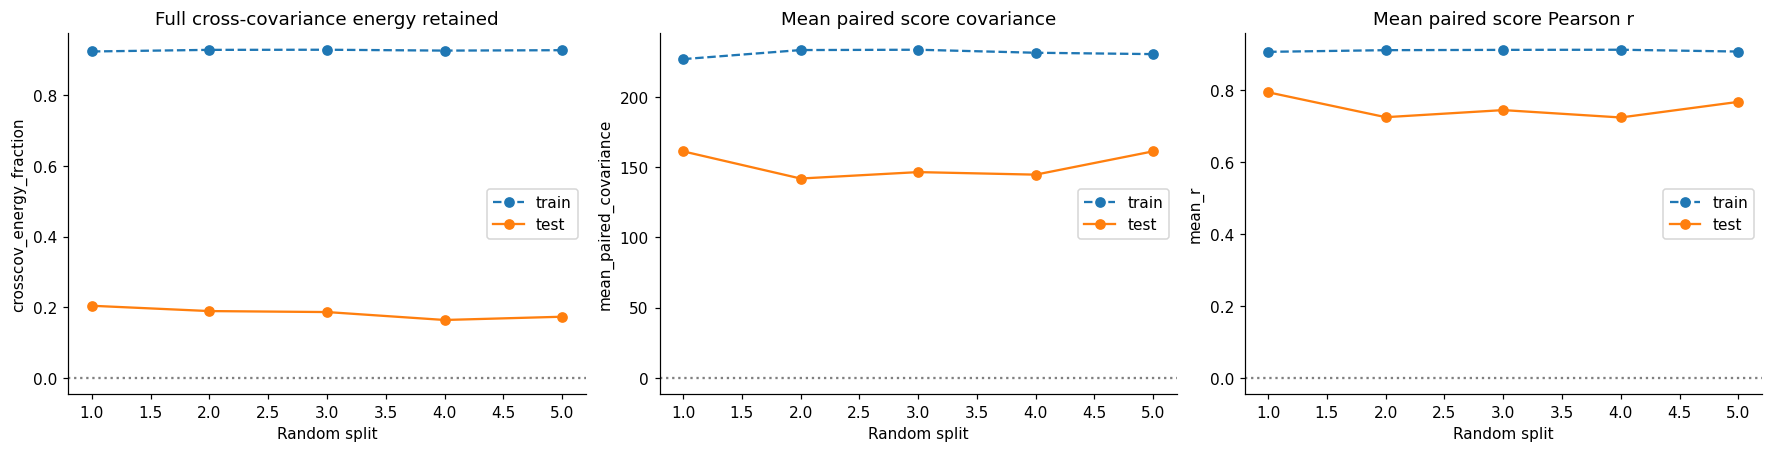

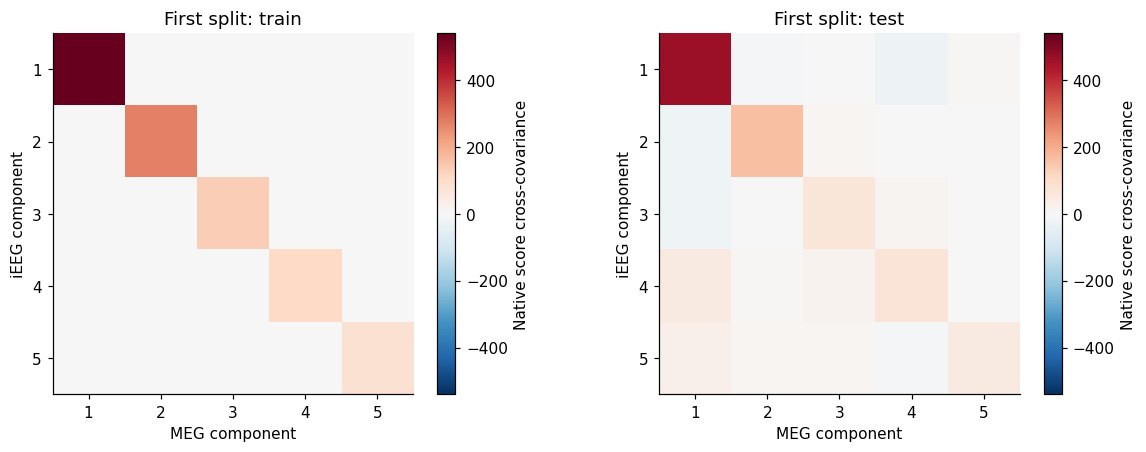

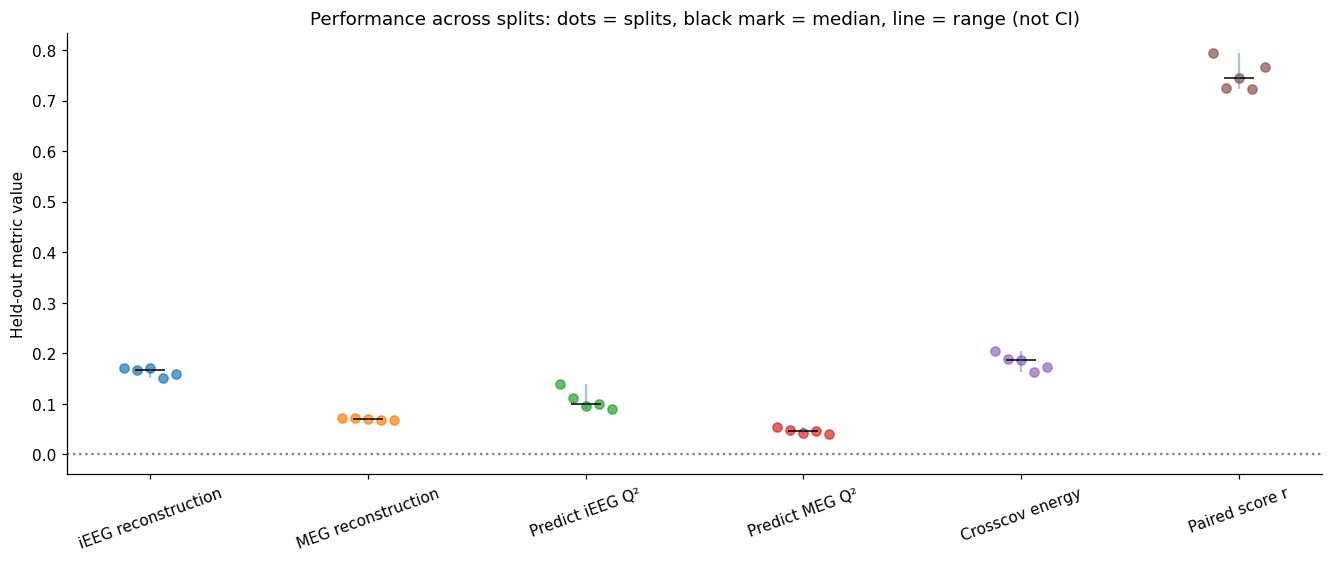

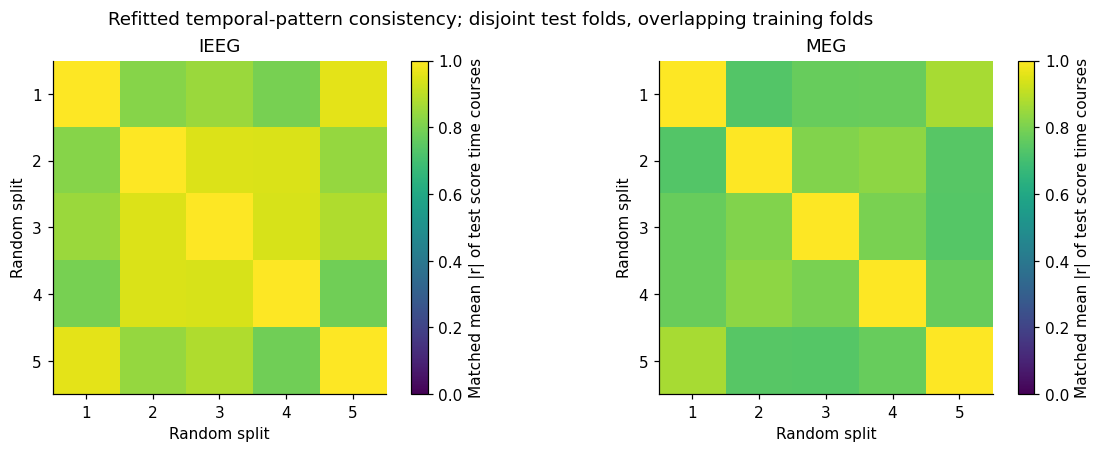

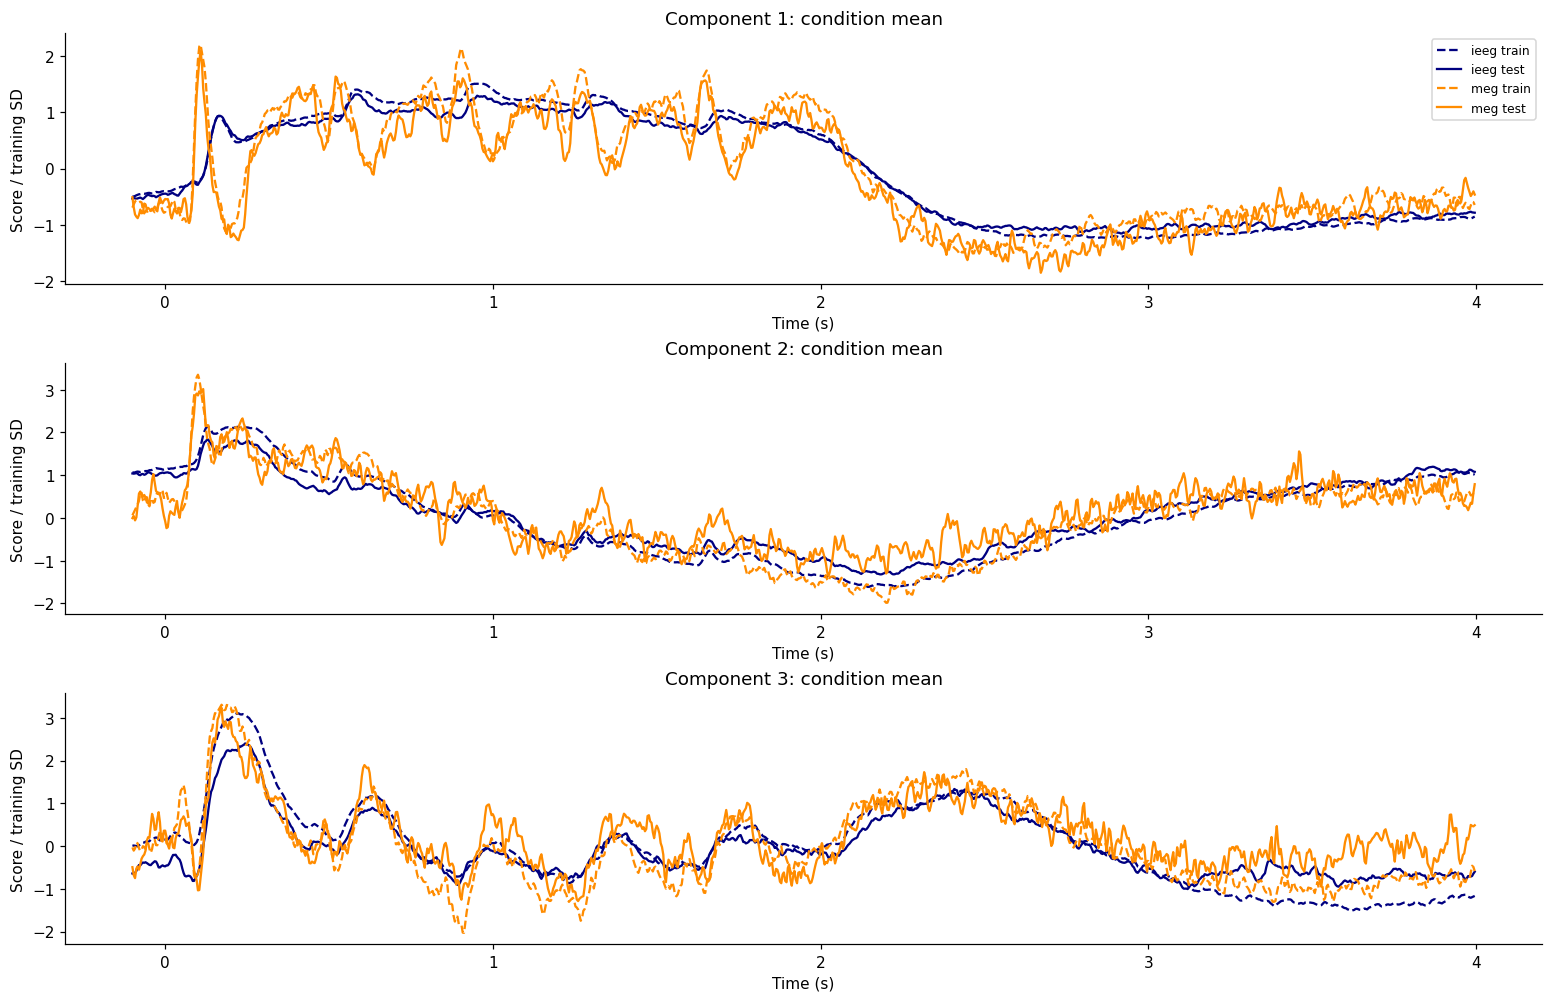

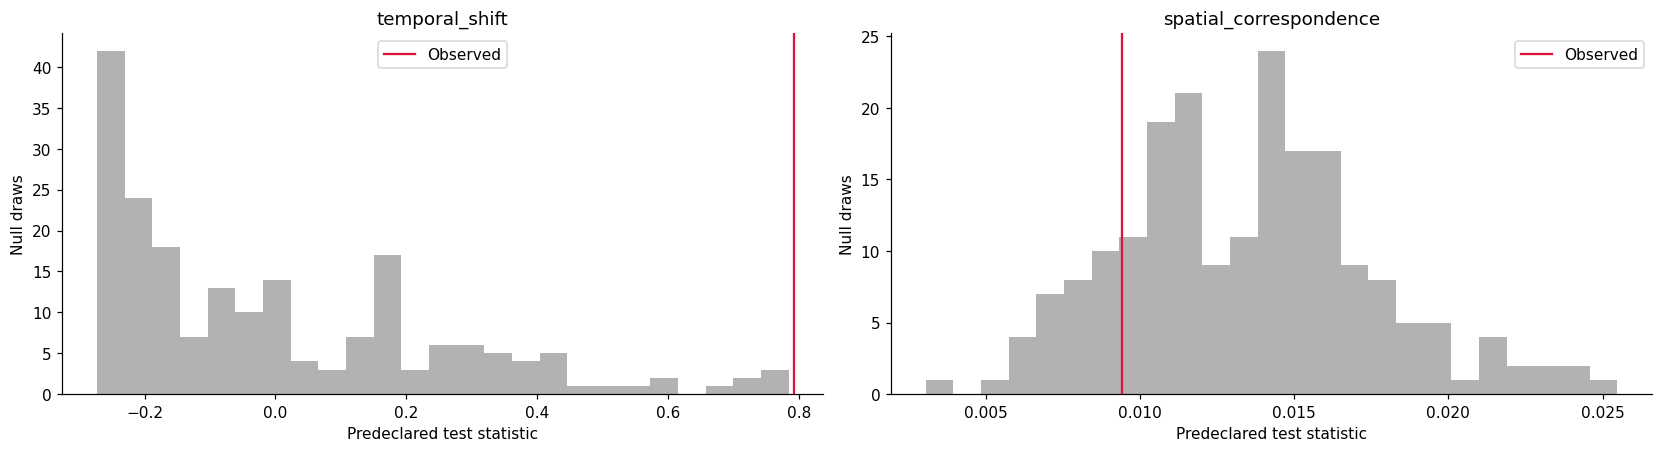

In [16]:
#display(result['components'].round(3))
plot_plssvd_validation(result)


## Stability across folds

`metric_summary.csv` reports mean, SD, median and range of each train/test metric. The performance-consistency plot shows every test split. These ranges are descriptive, not population confidence intervals.

`fold_stability.csv` compares the refitted score time courses between every pair of splits, separately in iEEG and MEG. It uses mean absolute Pearson correlation with one-to-one component matching, handling sign flips and changes in order. `fold_component_pairs.csv` records the assignments. This post-hoc matching describes stability only and never changes test prediction or cross-covariance metrics. Components may rotate across nearly degenerate solutions; simple matching is not rotation invariant.
Test trial sets are disjoint, but training sets overlap; folds are not independent replicates.


In [17]:
# Descriptive consistency across refitted folds with disjoint test trials and overlapping training trials.
display(result['fold_stability'].query("partition == 'test'").round(3))
display(result['metric_summary'].query("partition == 'test'").round(3))

,fold_a,fold_b,partition,modality,n_components,matched_abs_r,status
2,0,1,test,ieeg,5,0.817,ok
3,0,1,test,meg,5,0.734,ok
6,0,2,test,ieeg,5,0.850,ok
7,0,2,test,meg,5,0.767,ok
10,0,3,test,ieeg,5,0.794,ok
11,0,3,test,meg,5,0.772,ok
14,0,4,test,ieeg,5,0.958,ok
15,0,4,test,meg,5,0.870,ok
18,1,2,test,ieeg,5,0.948,ok
19,1,2,test,meg,5,0.811,ok


,partition,metric,count,mean,std,median,min,max
1,test,ieeg_reconstruction_fraction,5,0.164,0.009,0.167,0.151,0.171
3,test,predict_ieeg_q2,5,0.107,0.019,0.100,0.090,0.139
5,test,meg_reconstruction_fraction,5,0.070,0.002,0.069,0.068,0.072
7,test,predict_meg_q2,5,0.046,0.005,0.046,0.040,0.053
9,test,crosscov_energy_fraction,5,0.183,0.015,0.186,0.164,0.204
11,test,paired_crosscov_energy_fraction,5,0.178,0.016,0.180,0.158,0.199
13,test,mean_paired_covariance,5,151.251,9.424,146.605,142.025,161.425
15,test,total_crosscov_energy,5,1237825.773,155785.410,1252768.118,1066138.078,1468134.511
17,test,captured_crosscov_energy,5,225957.836,26523.881,209482.374,201513.859,255632.809
19,test,mean_r,5,0.750,0.030,0.744,0.723,0.793


## Null diagnostics for condition-averaged responses
Only fold 0 supplies these optional diagnostics; the model and preprocessing remain fixed.

1. **Temporal shift:** circularly shift the MEG condition-averaged test score time courses; statistic is mean signed paired component Pearson r.
2. **Spatial correspondence:** shuffle MEG forward-pattern rows within iEEG subject/region groups at electrode correspondences; statistic is mean absolute paired component pattern correlation.

These are conditional surrogate/correspondence diagnostics, not automatically calibrated significance tests. Condition-label and condition-contrast tests are omitted because the main analysis averages conditions. Fold consistency is reported separately.


In [12]:
display(result['null_tests'])
print(f'Results folder: {OUTPUT_DIR}')

,test,observed,tail_fraction,n_null,interpretation,note
0,temporal_shift,0.569047,0.005,199,surrogate / correspondence diagnostic,NaN
1,spatial_correspondence,0.019013,0.670,199,surrogate / correspondence diagnostic,NaN


Results folder: /users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/out/plssvd_eval/full_average
